<a href="https://colab.research.google.com/github/Vipinkumar20mar/Prediction-Model-for-Investor-Retention/blob/main/SIP_CHURN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [16]:
a=pd.read_csv('comprehensive_mutual_funds_data.csv')

In [17]:
a.head()

,scheme_name,min_sip,min_lumpsum,expense_ratio,fund_size_cr,fund_age_yr,fund_manager,sortino,alpha,sd,beta,sharpe,risk_level,amc_name,rating,category,sub_category,returns_1yr,returns_3yr,returns_5yr
0,Aditya Birla SL Active Debt Multi-Mgr FoF-Dir ...,100,100,0.27,10.0,10,Kaustubh Gupta,0.32,2.24,9.39,0.01,0.24,3,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,4.0,6.5,6.9
1,Aditya Birla SL Arbitrage Fund,1000,1000,0.36,4288.0,10,Lovelish Solanki,1.33,1.53,0.72,0.56,1.1,1,Aditya Birla Sun Life Mutual Fund,3,Hybrid,Arbitrage Mutual Funds,5.6,4.8,5.5
2,Aditya Birla SL Asset Allocator FoF-Dir Growth,1000,1000,0.53,157.0,10,Vinod Narayan Bhat,3.44,2.67,10.58,0.67,1.42,5,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,2.0,18.9,9.7
3,Aditya Birla SL Bal Bhavishya Yojna – Dir Growth,500,1000,0.76,637.0,4,Atul Penkar,2.18,-6.37,14.99,0.85,0.9,6,Aditya Birla Sun Life Mutual Fund,2,Solution Oriented,Childrens Funds,-0.7,17.1,NaN
4,Aditya Birla SL Balanced Advantage Fund,100,100,0.61,6386.0,10,Mohit Sharma,3.69,1.99,10.38,0.68,1.39,6,Aditya Birla Sun Life Mutual Fund,4,Hybrid,Dynamic Asset Allocation or Balanced Advantage,4.5,18.6,9.7


In [18]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   scheme_name    814 non-null    object 
 1   min_sip        814 non-null    int64  
 2   min_lumpsum    814 non-null    int64  
 3   expense_ratio  814 non-null    float64
 4   fund_size_cr   814 non-null    float64
 5   fund_age_yr    814 non-null    int64  
 6   fund_manager   814 non-null    object 
 7   sortino        814 non-null    object 
 8   alpha          814 non-null    object 
 9   sd             814 non-null    object 
 10  beta           814 non-null    object 
 11  sharpe         814 non-null    object 
 12  risk_level     814 non-null    int64  
 13  amc_name       814 non-null    object 
 14  rating         814 non-null    int64  
 15  category       814 non-null    object 
 16  sub_category   814 non-null    object 
 17  returns_1yr    814 non-null    float64
 18  returns_3y

In [21]:
a.isnull().sum()

,0
scheme_name,0
min_sip,0
min_lumpsum,0
expense_ratio,0
fund_size_cr,0
fund_age_yr,0
fund_manager,0
sortino,0
alpha,0
sd,0


In [20]:
a['returns_3yr'] = pd.to_numeric(a['returns_3yr'], errors='coerce')

In [15]:
a.head(2)

,returns_3yr
0,6.5
1,4.8


In [22]:
a['returns_3yr'].fillna(a['returns_3yr'].median(),inplace=True)

/tmp/ipykernel_9291/1679301373.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  a['returns_3yr'].fillna(a['returns_3yr'].median(),inplace=True)


In [25]:
a.isnull().sum()

,0
scheme_name,0
min_sip,0
min_lumpsum,0
expense_ratio,0
fund_size_cr,0
fund_age_yr,0
fund_manager,0
sortino,0
alpha,0
sd,0


In [24]:
a['returns_5yr']=a['returns_5yr'].fillna(a['returns_5yr'].median())

In [27]:
a.duplicated().sum()

np.int64(0)

In [30]:
a['returns_1yr'].describe()


,returns_1yr
count,814.000000
mean,3.921376
std,6.675502
min,-19.700000
25%,1.500000
50%,4.400000
75%,5.600000
max,130.800000


In [31]:
a['returns_3yr'].describe()


,returns_3yr
count,814.000000
mean,18.524693
std,11.951072
min,3.300000
25%,6.300000
50%,18.500000
75%,27.000000
max,71.400000


In [32]:
a['returns_5yr'].describe()

,returns_5yr
count,814.000000
mean,9.369533
std,3.319254
min,-4.100000
25%,7.100000
50%,8.900000
75%,11.500000
max,23.200000


In [33]:
a['rating'].describe()

,rating
count,814.000000
mean,2.641278
std,1.463476
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [34]:
a['risk_level'].describe()

,risk_level
count,814.000000
mean,4.400491
std,1.814741
min,1.000000
25%,3.000000
50%,6.000000
75%,6.000000
max,6.000000


In [55]:
a['churn'] = (
    (a['returns_1yr'] < 1.5) &
    (a['returns_3yr'] < 6.3) &
    (a['returns_5yr'] < 7.1) &
    (a['rating'] <= 2) |
    (a['risk_level'] >= 4)
).astype(int)

In [56]:
a['churn'].value_counts()

,count
churn,
1,510
0,304


In [37]:
X = a[[
    'returns_1yr',
    'returns_3yr',
    'returns_5yr',
    'rating',
    'risk_level'
]]

In [57]:
Y=a['churn']

In [58]:
X.shape

(814, 5)

In [59]:
Y.shape

(814,)

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [61]:
a.describe()

,min_sip,min_lumpsum,expense_ratio,fund_size_cr,fund_age_yr,risk_level,rating,returns_1yr,returns_3yr,returns_5yr,churn
count,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000,814.000000
mean,528.500000,3047.468059,0.713231,3812.854214,8.319410,4.400491,2.641278,3.921376,18.524693,9.369533,0.626536
std,369.184517,2514.619513,0.482161,7181.479475,2.640622,1.814741,1.463476,6.675502,11.951072,3.319254,0.484021
min,0.000000,0.000000,0.000000,2.380000,1.000000,1.000000,0.000000,-19.700000,3.300000,-4.100000,0.000000
25%,150.000000,500.000000,0.310000,175.250000,6.000000,3.000000,2.000000,1.500000,6.300000,7.100000,0.000000
50%,500.000000,5000.000000,0.615000,940.500000,10.000000,6.000000,3.000000,4.400000,18.500000,8.900000,1.000000
75%,1000.000000,5000.000000,1.030000,3819.000000,10.000000,6.000000,4.000000,5.600000,27.000000,11.500000,1.000000
max,2000.000000,25000.000000,2.590000,57052.000000,17.000000,6.000000,5.000000,130.800000,71.400000,23.200000,1.000000


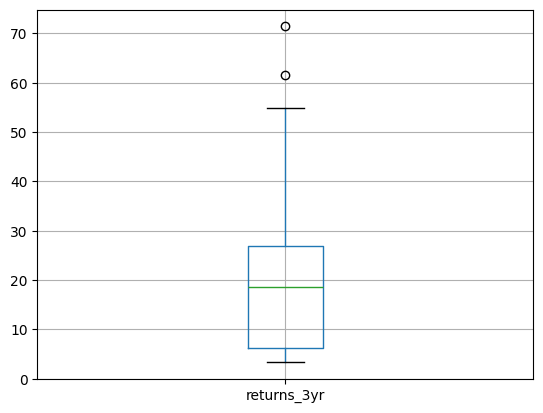

In [62]:
import matplotlib.pyplot as plt

a.boxplot(column='returns_3yr')

plt.show()

In [63]:
from sklearn.preprocessing import  RobustScaler
ro=RobustScaler()
X_train_ro=ro.fit_transform(X_train)
X_test_ro=ro.transform(X_test)

In [64]:
from sklearn.linear_model import LogisticRegression

In [65]:
l=LogisticRegression()

In [66]:
l.fit(X_train_ro,y_train)

LogisticRegression()

In [67]:
a['churn'].value_counts()

,count
churn,
1,510
0,304


In [68]:
y_pred=l.predict(X_test_ro)

In [69]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

In [70]:
print(accuracy)

0.9938650306748467


In [72]:
train_acc = l.score(X_train_ro, y_train)

print(train_acc)

1.0


In [73]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[ 56   1]
 [  0 106]]


In [74]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        57
           1       0.99      1.00      1.00       106

    accuracy                           0.99       163
   macro avg       1.00      0.99      0.99       163
weighted avg       0.99      0.99      0.99       163



In [78]:
c=pd.Series(y_pred)

In [79]:
c.value_counts()

,count
1,107
0,56


In [80]:
import pickle

In [82]:
pickle.dump(l, open('model.pkl', 'wb'))

In [83]:
a.head()

,scheme_name,min_sip,min_lumpsum,expense_ratio,fund_size_cr,fund_age_yr,fund_manager,sortino,alpha,sd,...,sharpe,risk_level,amc_name,rating,category,sub_category,returns_1yr,returns_3yr,returns_5yr,churn
0,Aditya Birla SL Active Debt Multi-Mgr FoF-Dir ...,100,100,0.27,10.0,10,Kaustubh Gupta,0.32,2.24,9.39,...,0.24,3,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,4.0,6.5,6.9,0
1,Aditya Birla SL Arbitrage Fund,1000,1000,0.36,4288.0,10,Lovelish Solanki,1.33,1.53,0.72,...,1.1,1,Aditya Birla Sun Life Mutual Fund,3,Hybrid,Arbitrage Mutual Funds,5.6,4.8,5.5,0
2,Aditya Birla SL Asset Allocator FoF-Dir Growth,1000,1000,0.53,157.0,10,Vinod Narayan Bhat,3.44,2.67,10.58,...,1.42,5,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,2.0,18.9,9.7,1
3,Aditya Birla SL Bal Bhavishya Yojna – Dir Growth,500,1000,0.76,637.0,4,Atul Penkar,2.18,-6.37,14.99,...,0.9,6,Aditya Birla Sun Life Mutual Fund,2,Solution Oriented,Childrens Funds,-0.7,17.1,8.9,1
4,Aditya Birla SL Balanced Advantage Fund,100,100,0.61,6386.0,10,Mohit Sharma,3.69,1.99,10.38,...,1.39,6,Aditya Birla Sun Life Mutual Fund,4,Hybrid,Dynamic Asset Allocation or Balanced Advantage,4.5,18.6,9.7,1


In [85]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison_df)

     Actual  Predicted
247       1          1
589       0          0
227       0          0
291       1          1
539       0          0
..      ...        ...
676       1          1
440       1          1
758       0          0
518       1          1
664       1          1

[163 rows x 2 columns]


In [87]:
d=pd.DataFrame(X_train_ro)

In [90]:
print(d.columns)

RangeIndex(start=0, stop=5, step=1)


In [91]:
print(X_train.columns)

Index(['returns_1yr', 'returns_3yr', 'returns_5yr', 'rating', 'risk_level'], dtype='object')


In [92]:
pickle.dump(ro, open('scaler.pkl', 'wb'))